In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense, Dropout
import streamlit as st
from PIL import Image

In [6]:
train_datagen = ImageDataGenerator( #data augmentation
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = train_datagen.flow_from_directory(
    "training_set/training_set",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.


In [8]:
images, labels = next(train_data)

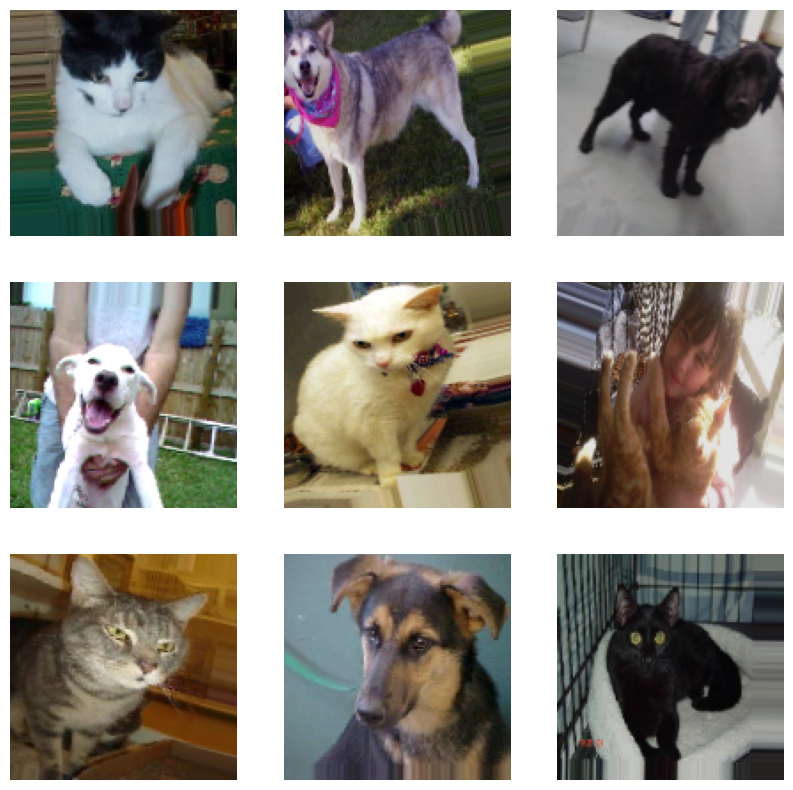

In [9]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

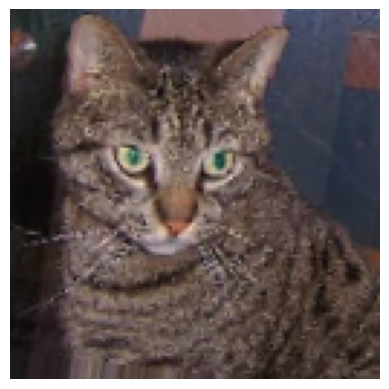

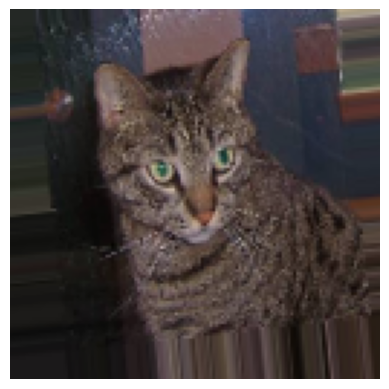

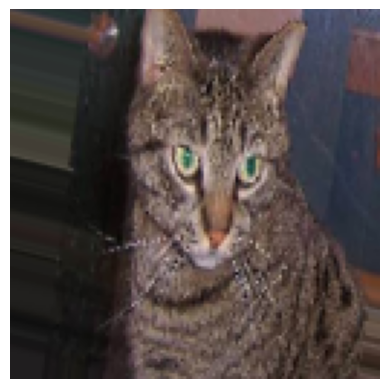

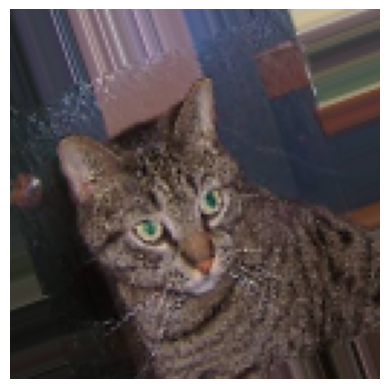

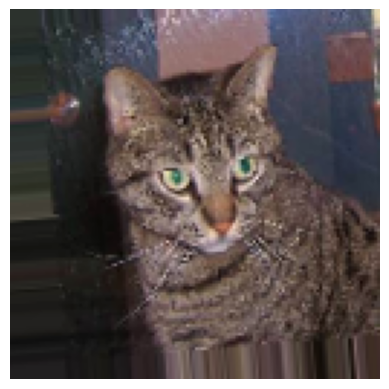

In [10]:
img = image.load_img("training_set/training_set/cats/cat.1.jpg", target_size=(128,128))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

i = 0
for batch in train_datagen.flow(x, batch_size=1):
    
    plt.imshow(batch[0])
    plt.axis("off")
    plt.show()
    
    i += 1
    if i == 5:
        break

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "test_set/test_set",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 2023 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

c:\Users\Hp\OneDrive\Documents\Scraping_task_debi_1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 228s 900ms/step - accuracy: 0.5601 - loss: 0.6861 - val_accuracy: 0.6510 - val_loss: 0.6534
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 274ms/step - accuracy: 0.6406 - loss: 0.6431 - val_accuracy: 0.6480 - val_loss: 0.6257
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 713ms/step - accuracy: 0.6525 - loss: 0.6249 - val_accuracy: 0.6629 - val_loss: 0.6033
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 193ms/step - accuracy: 0.6822 - loss: 0.5981 - val_accuracy: 0.7420 - val_loss: 0.5318
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 195ms/step - accuracy: 0.7019 - loss: 0.5693 - val_accuracy: 0.7558 - val_loss: 0.5267
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 198ms/step - accuracy: 0.7184 - loss: 0.5555 - val_accuracy: 0.7435 - val_loss: 0.5318
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 200ms/step - accuracy: 0.7364 - loss: 0.5322 - val_accuracy: 0.7835 - val_loss: 0.4710
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.7569 - loss:

In [16]:
model.evaluate(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7954 - loss: 0.4411


[0.44110506772994995, 0.7953534126281738]

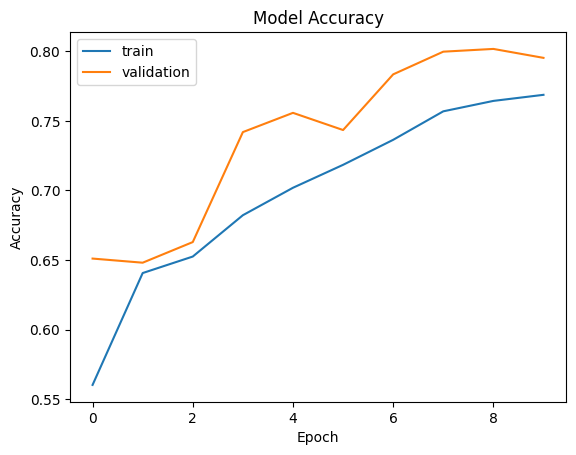

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train","validation"])
plt.show()

In [18]:
img = image.load_img("dog2.jpg",target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array/255
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Dog


In [19]:
img = image.load_img("cat.jpg",target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array/255
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Cat


# improving Accuracy

## increasing number of epochs

In [20]:
history2 = model.fit(
    train_data,
    epochs=25,
    validation_data=test_data
)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 196ms/step - accuracy: 0.7825 - loss: 0.4660 - val_accuracy: 0.8136 - val_loss: 0.4160
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.7866 - loss: 0.4590 - val_accuracy: 0.7766 - val_loss: 0.4749
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.7925 - loss: 0.4494 - val_accuracy: 0.8196 - val_loss: 0.4160
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.7979 - loss: 0.4399 - val_accuracy: 0.8319 - val_loss: 0.3803
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 201ms/step - accuracy: 0.8009 - loss: 0.4319 - val_accuracy: 0.8314 - val_loss: 0.3882
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 203ms/step - accuracy: 0.8110 - loss: 0.4131 - val_accuracy: 0.8418 - val_loss: 0.3559
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.8181 - loss: 0.4054 - val_accuracy: 0.8487 - val_loss: 0.3494
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.8256 - loss: 0

In [21]:
model.evaluate(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8927 - loss: 0.2675


[0.26752591133117676, 0.8927335739135742]

In [22]:
model.save("cat_dog_model.h5")

In [23]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
